## Etapa 1: Verificación de datasets preparados para Modeling

In [1]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
objetos_necesarios = [
    "X_train_final",
    "X_test_final",
    "X_train_lr_selected",
    "X_test_lr_selected",
    "X_train_rf_selected",
    "X_test_rf_selected",
    "y_train",
    "y_test"
]

print("===== VERIFICACIÓN DE OBJETOS NECESARIOS =====\n")

objetos_faltantes = []

for obj in objetos_necesarios:
    if obj in globals():
        print(f"{obj}: existe")
    else:
        print(f"{obj}: NO existe")
        objetos_faltantes.append(obj)

if len(objetos_faltantes) > 0:
    print("\nObjetos faltantes:", objetos_faltantes)
    print("Debes ejecutar antes las etapas finales de Data Preparation & Feature Engineering.")
else:
    print("\nTodos los objetos necesarios existen.")

===== VERIFICACIÓN DE OBJETOS NECESARIOS =====

X_train_final: NO existe
X_test_final: NO existe
X_train_lr_selected: NO existe
X_test_lr_selected: NO existe
X_train_rf_selected: NO existe
X_test_rf_selected: NO existe
y_train: NO existe
y_test: NO existe

Objetos faltantes: ['X_train_final', 'X_test_final', 'X_train_lr_selected', 'X_test_lr_selected', 'X_train_rf_selected', 'X_test_rf_selected', 'y_train', 'y_test']
Debes ejecutar antes las etapas finales de Data Preparation & Feature Engineering.


In [3]:
print("===== DIMENSIONES DE DATASETS =====\n")

X_train_final = pd.read_csv("X_train_final.csv")
X_test_final = pd.read_csv("X_test_final.csv")
X_train_lr_selected = pd.read_csv("X_train_lr_selected.csv")
X_test_lr_selected = pd.read_csv("X_test_lr_selected.csv")
X_train_rf_selected = pd.read_csv("X_train_rf_selected.csv")
X_test_rf_selected = pd.read_csv("X_test_rf_selected.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

datasets_modeling = {
    "X_train_final": X_train_final,
    "X_test_final": X_test_final,
    "X_train_lr_selected": X_train_lr_selected,
    "X_test_lr_selected": X_test_lr_selected,
    "X_train_rf_selected": X_train_rf_selected,
    "X_test_rf_selected": X_test_rf_selected
}

for nombre, dataset in datasets_modeling.items():
    print(f"{nombre}: {dataset.shape}")

print("\ny_train:", y_train.shape)
print("y_test :", y_test.shape)

===== DIMENSIONES DE DATASETS =====

X_train_final: (3999, 81)
X_test_final: (1001, 81)
X_train_lr_selected: (3999, 30)
X_test_lr_selected: (1001, 30)
X_train_rf_selected: (3999, 30)
X_test_rf_selected: (1001, 30)

y_train: (3999, 1)
y_test : (1001, 1)


In [4]:
print("===== VERIFICACIÓN DE VALORES NULOS =====\n")

for nombre, dataset in datasets_modeling.items():
    total_nulos = dataset.isnull().sum().sum()
    print(f"{nombre}: {total_nulos} valores nulos")

print(f"\ny_train: {y_train.isnull().sum()} valores nulos")
print(f"y_test : {y_test.isnull().sum()} valores nulos")

===== VERIFICACIÓN DE VALORES NULOS =====

X_train_final: 0 valores nulos
X_test_final: 0 valores nulos
X_train_lr_selected: 0 valores nulos
X_test_lr_selected: 0 valores nulos
X_train_rf_selected: 0 valores nulos
X_test_rf_selected: 0 valores nulos

y_train: nivel_prioridad    0
dtype: int64 valores nulos
y_test : nivel_prioridad    0
dtype: int64 valores nulos


In [5]:
print("===== VERIFICACIÓN DE COLUMNAS DE TEXTO =====\n")

for nombre, dataset in datasets_modeling.items():
    columnas_texto = dataset.select_dtypes(include=["object", "category"]).columns.tolist()
    print(f"{nombre}: {len(columnas_texto)} columnas de texto")

    if len(columnas_texto) > 0:
        print(columnas_texto)

===== VERIFICACIÓN DE COLUMNAS DE TEXTO =====

X_train_final: 0 columnas de texto
X_test_final: 0 columnas de texto
X_train_lr_selected: 0 columnas de texto
X_test_lr_selected: 0 columnas de texto
X_train_rf_selected: 0 columnas de texto
X_test_rf_selected: 0 columnas de texto


In [6]:
print("===== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO =====\n")

distribucion_train = pd.DataFrame({
    "frecuencia_train": y_train.value_counts(),
    "porcentaje_train": (y_train.value_counts(normalize=True) * 100).round(2)
})

distribucion_test = pd.DataFrame({
    "frecuencia_test": y_test.value_counts(),
    "porcentaje_test": (y_test.value_counts(normalize=True) * 100).round(2)
})

display(distribucion_train)
display(distribucion_test)

===== DISTRIBUCIÓN DE LA VARIABLE OBJETIVO =====



,frecuencia_train,porcentaje_train
nivel_prioridad,,
medio,1427,35.68
alto,1383,34.58
bajo,1189,29.73


,frecuencia_test,porcentaje_test
nivel_prioridad,,
medio,363,36.26
bajo,331,33.07
alto,307,30.67


In [7]:
print("===== COMPARACIÓN DE DISTRIBUCIÓN TRAIN VS TEST =====\n")

comparacion_clases = pd.DataFrame({
    "train_%": (y_train.value_counts(normalize=True) * 100).round(2),
    "test_%": (y_test.value_counts(normalize=True) * 100).round(2)
})

comparacion_clases["diferencia_abs_%"] = (
    comparacion_clases["train_%"] - comparacion_clases["test_%"]
).abs().round(2)

display(comparacion_clases)

===== COMPARACIÓN DE DISTRIBUCIÓN TRAIN VS TEST =====



,train_%,test_%,diferencia_abs_%
nivel_prioridad,,,
alto,34.58,30.67,3.91
bajo,29.73,33.07,3.34
medio,35.68,36.26,0.58


In [8]:
print("===== VALIDACIÓN FINAL DE ETAPA 1 =====\n")

y_train_valid = y_train.squeeze()
y_test_valid = y_test.squeeze()

validacion = {
    "sin_nulos_X": all(
        dataset.isnull().sum().sum() == 0
        for dataset in datasets_modeling.values()
    ),

    "sin_nulos_y": (
        y_train_valid.isnull().sum() == 0 and
        y_test_valid.isnull().sum() == 0
    ),

    "sin_columnas_texto": all(
        len(dataset.select_dtypes(include=["object", "category"]).columns) == 0
        for dataset in datasets_modeling.values()
    ),

    "mismas_filas_train_lr": X_train_lr_selected.shape[0] == len(y_train_valid),
    "mismas_filas_test_lr": X_test_lr_selected.shape[0] == len(y_test_valid),

    "mismas_filas_train_rf": X_train_rf_selected.shape[0] == len(y_train_valid),
    "mismas_filas_test_rf": X_test_rf_selected.shape[0] == len(y_test_valid),

    "tres_clases_objetivo": set(y_train_valid.unique()) == set(["bajo", "medio", "alto"])
}

for criterio, estado in validacion.items():
    print(f"{criterio}: {'OK' if estado else 'REVISAR'}")

if all(validacion.values()):
    print("\nResultado final: los datasets están listos para iniciar el baseline.")
else:
    print("\nResultado final: hay aspectos que deben revisarse antes del baseline.")

===== VALIDACIÓN FINAL DE ETAPA 1 =====

sin_nulos_X: OK
sin_nulos_y: OK
sin_columnas_texto: OK
mismas_filas_train_lr: OK
mismas_filas_test_lr: OK
mismas_filas_train_rf: OK
mismas_filas_test_rf: OK
tres_clases_objetivo: OK

Resultado final: los datasets están listos para iniciar el baseline.


## Etapa 2: Baseline — modelos y métricas de desempeño iniciales

In [9]:
y_train_model = y_train.squeeze()
y_test_model = y_test.squeeze()

print("Forma de y_train_model:", y_train_model.shape)
print("Forma de y_test_model :", y_test_model.shape)

print("\nClases en entrenamiento:", sorted(y_train_model.unique()))
print("Clases en prueba        :", sorted(y_test_model.unique()))

Forma de y_train_model: (3999,)
Forma de y_test_model : (1001,)

Clases en entrenamiento: ['alto', 'bajo', 'medio']
Clases en prueba        : ['alto', 'bajo', 'medio']


In [10]:
def evaluar_modelo_baseline(nombre_modelo, y_real, y_pred):
    """
    Calcula métricas de desempeño iniciales para clasificación multiclase.
    En esta etapa baseline se reportan varias métricas,
    pero todavía no se selecciona una métrica principal.
    """

    accuracy = accuracy_score(y_real, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_real,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_real,
        y_pred,
        average="weighted",
        zero_division=0
    )

    reporte_dict = classification_report(
        y_real,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    resultados = {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

    clases = ["bajo", "medio", "alto"]

    for clase in clases:
        resultados[f"precision_{clase}"] = reporte_dict[clase]["precision"]
        resultados[f"recall_{clase}"] = reporte_dict[clase]["recall"]
        resultados[f"f1_{clase}"] = reporte_dict[clase]["f1-score"]

    return resultados

In [11]:
# ------------------------------------------------------------
# Entrenamiento de modelos baseline
# ------------------------------------------------------------

resultados_baseline = []

# ============================================================
# Modelo 1: Dummy Classifier
# ============================================================

dummy_baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy_baseline.fit(X_train_lr_selected, y_train_model)
y_pred_dummy = dummy_baseline.predict(X_test_lr_selected)

resultados_baseline.append(
    evaluar_modelo_baseline(
        "Dummy Classifier",
        y_test_model,
        y_pred_dummy
    )
)


# ============================================================
# Modelo 2: Regresión Logística Multinomial
# ============================================================

lr_baseline = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)

lr_baseline.fit(X_train_lr_selected, y_train_model)
y_pred_lr = lr_baseline.predict(X_test_lr_selected)

resultados_baseline.append(
    evaluar_modelo_baseline(
        "Regresión Logística Multinomial",
        y_test_model,
        y_pred_lr
    )
)


# ============================================================
# Modelo 3: Random Forest Classifier
# ============================================================

rf_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_rf_selected, y_train_model)
y_pred_rf = rf_baseline.predict(X_test_rf_selected)

resultados_baseline.append(
    evaluar_modelo_baseline(
        "Random Forest Classifier",
        y_test_model,
        y_pred_rf
    )
)

print("Entrenamiento de modelos baseline completado.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Entrenamiento de modelos baseline completado.


In [12]:
# ------------------------------------------------------------
# Tabla comparativa de métricas de desempeño iniciales
# ------------------------------------------------------------

df_resultados_baseline = pd.DataFrame(resultados_baseline)

columnas_ordenadas = [
    "modelo",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "precision_bajo",
    "recall_bajo",
    "f1_bajo",
    "precision_medio",
    "recall_medio",
    "f1_medio",
    "precision_alto",
    "recall_alto",
    "f1_alto"
]

df_resultados_baseline = df_resultados_baseline[columnas_ordenadas]

display(df_resultados_baseline.round(4))

,modelo,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,precision_bajo,recall_bajo,f1_bajo,precision_medio,recall_medio,f1_medio,precision_alto,recall_alto,f1_alto
0,Dummy Classifier,0.3626,0.1209,0.3333,0.1774,0.1315,0.3626,0.1930,0.0000,0.0000,0.0000,0.3626,1.0000,0.5323,0.0000,0.0000,0.0000
1,Regresión Logística Multinomial,0.8791,0.8808,0.8821,0.8806,0.8809,0.8791,0.8792,0.9560,0.9184,0.9368,0.8501,0.8127,0.8310,0.8363,0.9153,0.8740
2,Random Forest Classifier,0.8791,0.8819,0.8814,0.8810,0.8814,0.8791,0.8796,0.9647,0.9094,0.9362,0.8361,0.8292,0.8326,0.8450,0.9055,0.8742


In [13]:
# ------------------------------------------------------------
# Reportes completos de clasificación por modelo
# ------------------------------------------------------------

print("============================================================")
print("REPORTE DE CLASIFICACIÓN - DUMMY CLASSIFIER")
print("============================================================")
print(classification_report(y_test_model, y_pred_dummy, zero_division=0))

print("============================================================")
print("REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA MULTINOMIAL")
print("============================================================")
print(classification_report(y_test_model, y_pred_lr, zero_division=0))

print("============================================================")
print("REPORTE DE CLASIFICACIÓN - RANDOM FOREST CLASSIFIER")
print("============================================================")
print(classification_report(y_test_model, y_pred_rf, zero_division=0))

REPORTE DE CLASIFICACIÓN - DUMMY CLASSIFIER
              precision    recall  f1-score   support

        alto       0.00      0.00      0.00       307
        bajo       0.00      0.00      0.00       331
       medio       0.36      1.00      0.53       363

    accuracy                           0.36      1001
   macro avg       0.12      0.33      0.18      1001
weighted avg       0.13      0.36      0.19      1001

REPORTE DE CLASIFICACIÓN - REGRESIÓN LOGÍSTICA MULTINOMIAL
              precision    recall  f1-score   support

        alto       0.84      0.92      0.87       307
        bajo       0.96      0.92      0.94       331
       medio       0.85      0.81      0.83       363

    accuracy                           0.88      1001
   macro avg       0.88      0.88      0.88      1001
weighted avg       0.88      0.88      0.88      1001

REPORTE DE CLASIFICACIÓN - RANDOM FOREST CLASSIFIER
              precision    recall  f1-score   support

        alto       0.84     

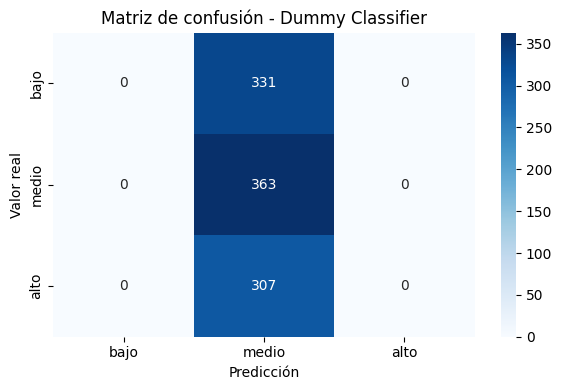

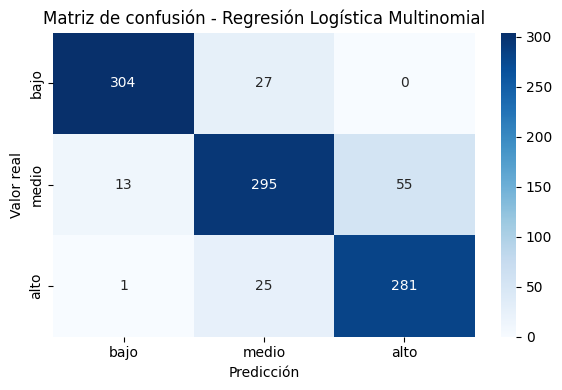

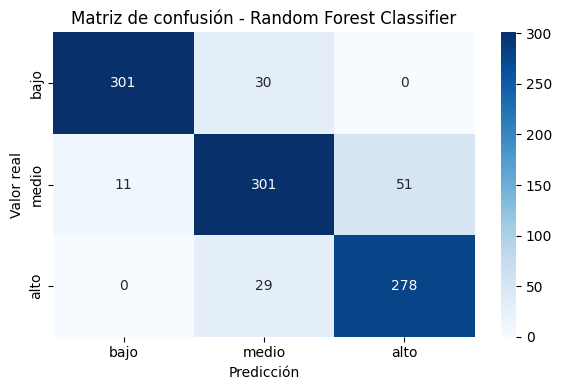

In [14]:
# ------------------------------------------------------------
# Matrices de confusión
# ------------------------------------------------------------

clases_ordenadas = ["bajo", "medio", "alto"]

def graficar_matriz_confusion(y_real, y_pred, titulo):
    matriz = confusion_matrix(
        y_real,
        y_pred,
        labels=clases_ordenadas
    )

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=clases_ordenadas,
        yticklabels=clases_ordenadas
    )

    plt.title(titulo)
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.show()


graficar_matriz_confusion(
    y_test_model,
    y_pred_dummy,
    "Matriz de confusión - Dummy Classifier"
)

graficar_matriz_confusion(
    y_test_model,
    y_pred_lr,
    "Matriz de confusión - Regresión Logística Multinomial"
)

graficar_matriz_confusion(
    y_test_model,
    y_pred_rf,
    "Matriz de confusión - Random Forest Classifier"
)

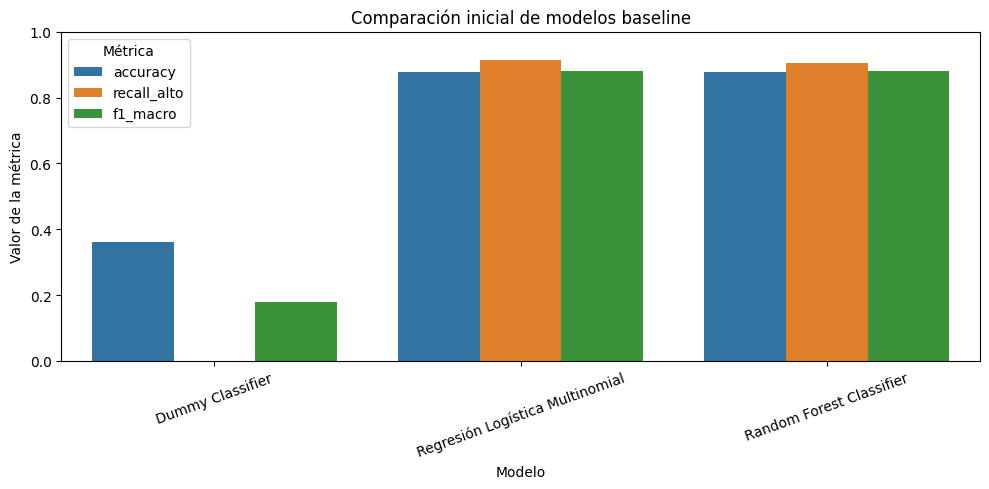

In [15]:
# ------------------------------------------------------------
# Gráfico comparativo de métricas iniciales
# ------------------------------------------------------------

metricas_para_grafico = [
    "accuracy",
    "recall_alto",
    "f1_macro"
]

df_grafico_baseline = df_resultados_baseline[
    ["modelo"] + metricas_para_grafico
].melt(
    id_vars="modelo",
    var_name="metrica",
    value_name="valor"
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_grafico_baseline,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Comparación inicial de modelos baseline")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

# Análisis — Etapa 2: Baseline de modelos

## 1. Verificación inicial

La variable objetivo quedó correctamente preparada como Series:

* `y_train_model`: **3999 registros**
* `y_test_model`: **1001 registros**
* Clases presentes: **alto, bajo, medio**

Esto confirma que los modelos pudieron entrenarse y evaluarse sin problemas de formato.

---

## 2. Dummy Classifier

El **Dummy Classifier** obtuvo:

| Modelo           | Accuracy | Recall alto | F1 macro |
| ---------------- | -------: | ----------: | -------: |
| Dummy Classifier |   0.3626 |      0.0000 |   0.1774 |

Este modelo predijo todos los casos como **medio**, porque esa era la clase más frecuente en el conjunto de prueba.

En su matriz de confusión se observa que:

* 331 pacientes reales **bajo** fueron clasificados como **medio**.
* 363 pacientes reales **medio** fueron clasificados correctamente como **medio**.
* 307 pacientes reales **alto** fueron clasificados como **medio**.

Por eso su **recall de alto es 0.00**. No detectó ningún paciente de prioridad alta. Este resultado confirma que el Dummy solo funciona como referencia mínima y no es útil para el problema.

---

## 3. Regresión Logística Multinomial

La **Regresión Logística Multinomial** obtuvo:

| Métrica     |  Valor |
| ----------- | -----: |
| Accuracy    | 0.8791 |
| F1 macro    | 0.8806 |
| Recall alto | 0.9153 |
| F1 alto     | 0.8740 |

Este modelo mostró un desempeño fuerte desde el baseline. Detectó correctamente **281 de 307** pacientes reales de prioridad alta.

En la matriz de confusión:

* De los 331 casos reales **bajo**, clasificó correctamente 304.
* De los 363 casos reales **medio**, clasificó correctamente 295.
* De los 307 casos reales **alto**, clasificó correctamente 281.

Sus errores en la clase alta fueron:

* 25 pacientes **alto** clasificados como **medio**.
* 1 paciente **alto** clasificado como **bajo**.

El modelo tiene buen rendimiento general, pero ese único caso de **alto → bajo** debe vigilarse porque representa un error crítico.

---

## 4. Random Forest Classifier

El **Random Forest Classifier** obtuvo:

| Métrica     |  Valor |
| ----------- | -----: |
| Accuracy    | 0.8791 |
| F1 macro    | 0.8810 |
| Recall alto | 0.9055 |
| F1 alto     | 0.8742 |

Random Forest también tuvo un desempeño fuerte. Detectó correctamente **278 de 307** pacientes reales de prioridad alta.

En la matriz de confusión:

* De los 331 casos reales **bajo**, clasificó correctamente 301.
* De los 363 casos reales **medio**, clasificó correctamente 301.
* De los 307 casos reales **alto**, clasificó correctamente 278.

Sus errores en la clase alta fueron:

* 29 pacientes **alto** clasificados como **medio**.
* 0 pacientes **alto** clasificados como **bajo**.

Este punto es importante: aunque Random Forest detectó ligeramente menos casos altos que la Regresión Logística, no cometió el error más grave de mandar un paciente **alto** directamente a **bajo**.

---

## 5. Comparación inicial

| Modelo                          | Accuracy | Recall alto | F1 macro | Observación                  |
| ------------------------------- | -------: | ----------: | -------: | ---------------------------- |
| Dummy Classifier                |   0.3626 |      0.0000 |   0.1774 | No aprende patrones reales   |
| Regresión Logística Multinomial |   0.8791 |      0.9153 |   0.8806 | Mejor recall para clase alto |
| Random Forest Classifier        |   0.8791 |      0.9055 |   0.8810 | Evita errores alto → bajo    |

Ambos modelos reales superan claramente al Dummy Classifier. La diferencia entre Regresión Logística y Random Forest es pequeña, pero cada uno tiene una ventaja distinta:

La **Regresión Logística Multinomial** tiene mejor detección de la clase **alto**, porque su recall alto es **0.9153** frente a **0.9055** de Random Forest.

El **Random Forest Classifier** tiene una ventaja en la matriz de confusión, porque no clasificó ningún paciente real de prioridad **alto** como **bajo**.

---

# Conclusión — Etapa 2

Los resultados baseline muestran que el problema sí puede ser aprendido por modelos supervisados, ya que tanto Regresión Logística Multinomial como Random Forest superan ampliamente al Dummy Classifier.

La **Regresión Logística Multinomial** aparece como el modelo más fuerte para detectar pacientes de prioridad **alto**, porque obtuvo el mayor recall en esa clase con **0.9153**. Sin embargo, el **Random Forest Classifier** también es competitivo y presenta una ventaja importante: no cometió errores críticos del tipo **alto → bajo**.

Por ahora, no se selecciona todavía el modelo final. Esta etapa solo presenta el desempeño inicial. La siguiente etapa debe centrarse en formalizar la **selección de la métrica principal y la métrica auxiliar**, considerando que el objetivo del proyecto no es solo acertar en promedio, sino evitar que pacientes de prioridad alta sean subestimados.


## Etapa 3 — Análisis del baseline y errores críticos

In [16]:
columnas_enfoque = [
    "modelo",
    "accuracy",
    "recall_alto",
    "f1_alto",
    "f1_macro",
    "precision_alto"
]

df_baseline_enfoque = df_resultados_baseline[columnas_enfoque].copy()

display(df_baseline_enfoque.round(4))

,modelo,accuracy,recall_alto,f1_alto,f1_macro,precision_alto
0,Dummy Classifier,0.3626,0.0000,0.0000,0.1774,0.0000
1,Regresión Logística Multinomial,0.8791,0.9153,0.8740,0.8806,0.8363
2,Random Forest Classifier,0.8791,0.9055,0.8742,0.8810,0.8450


In [17]:
# ------------------------------------------------------------
# 2. Función para calcular errores críticos de prioridad alta
# ------------------------------------------------------------

clases_ordenadas = ["bajo", "medio", "alto"]

def calcular_errores_criticos(nombre_modelo, y_real, y_pred):
    matriz = confusion_matrix(
        y_real,
        y_pred,
        labels=clases_ordenadas
    )

    # Índices según clases_ordenadas
    idx_bajo = clases_ordenadas.index("bajo")
    idx_medio = clases_ordenadas.index("medio")
    idx_alto = clases_ordenadas.index("alto")

    total_alto_real = matriz[idx_alto, :].sum()
    alto_correcto = matriz[idx_alto, idx_alto]
    alto_predicho_medio = matriz[idx_alto, idx_medio]
    alto_predicho_bajo = matriz[idx_alto, idx_bajo]

    errores_alto_total = alto_predicho_medio + alto_predicho_bajo

    if total_alto_real > 0:
        porcentaje_error_alto = errores_alto_total / total_alto_real
        porcentaje_alto_a_bajo = alto_predicho_bajo / total_alto_real
        porcentaje_alto_a_medio = alto_predicho_medio / total_alto_real
    else:
        porcentaje_error_alto = 0
        porcentaje_alto_a_bajo = 0
        porcentaje_alto_a_medio = 0

    return {
        "modelo": nombre_modelo,
        "total_real_alto": total_alto_real,
        "alto_correcto": alto_correcto,
        "alto_predicho_medio": alto_predicho_medio,
        "alto_predicho_bajo": alto_predicho_bajo,
        "errores_alto_total": errores_alto_total,
        "porcentaje_error_alto": porcentaje_error_alto,
        "porcentaje_alto_a_medio": porcentaje_alto_a_medio,
        "porcentaje_alto_a_bajo": porcentaje_alto_a_bajo
    }


errores_criticos = []

errores_criticos.append(
    calcular_errores_criticos(
        "Dummy Classifier",
        y_test_model,
        y_pred_dummy
    )
)

errores_criticos.append(
    calcular_errores_criticos(
        "Regresión Logística Multinomial",
        y_test_model,
        y_pred_lr
    )
)

errores_criticos.append(
    calcular_errores_criticos(
        "Random Forest Classifier",
        y_test_model,
        y_pred_rf
    )
)

df_errores_criticos = pd.DataFrame(errores_criticos)

display(df_errores_criticos.round(4))

,modelo,total_real_alto,alto_correcto,alto_predicho_medio,alto_predicho_bajo,errores_alto_total,porcentaje_error_alto,porcentaje_alto_a_medio,porcentaje_alto_a_bajo
0,Dummy Classifier,307,0,307,0,307,1.0000,1.0000,0.0000
1,Regresión Logística Multinomial,307,281,25,1,26,0.0847,0.0814,0.0033
2,Random Forest Classifier,307,278,29,0,29,0.0945,0.0945,0.0000


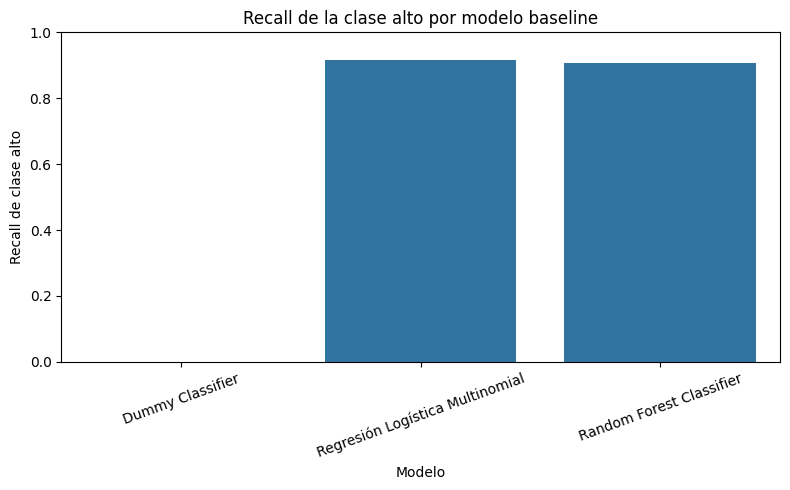

In [18]:
# ------------------------------------------------------------
# 3. Gráfico de recall de la clase alto
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_baseline_enfoque,
    x="modelo",
    y="recall_alto"
)

plt.title("Recall de la clase alto por modelo baseline")
plt.xlabel("Modelo")
plt.ylabel("Recall de clase alto")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

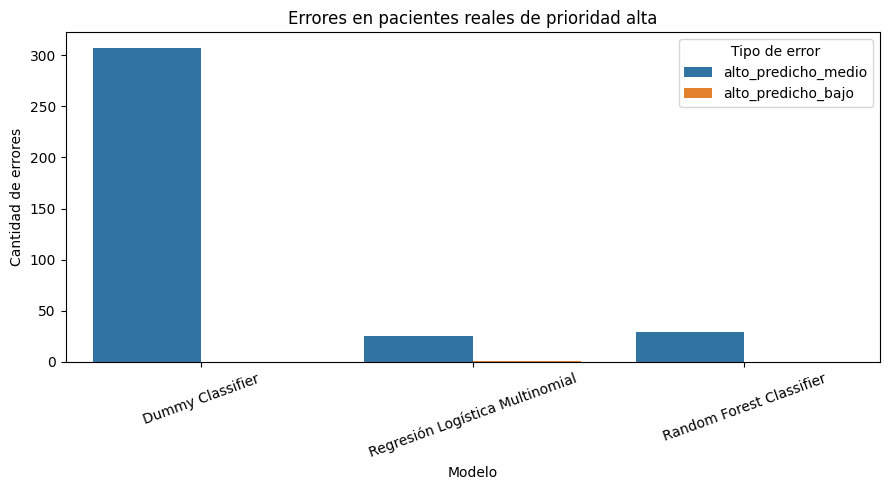

In [19]:
# ------------------------------------------------------------
# 4. Gráfico de errores en pacientes reales de prioridad alta
# ------------------------------------------------------------

df_errores_grafico = df_errores_criticos[
    [
        "modelo",
        "alto_predicho_medio",
        "alto_predicho_bajo"
    ]
].melt(
    id_vars="modelo",
    var_name="tipo_error",
    value_name="cantidad"
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_errores_grafico,
    x="modelo",
    y="cantidad",
    hue="tipo_error"
)

plt.title("Errores en pacientes reales de prioridad alta")
plt.xlabel("Modelo")
plt.ylabel("Cantidad de errores")
plt.xticks(rotation=20)
plt.legend(title="Tipo de error")
plt.tight_layout()
plt.show()

In [20]:
# ------------------------------------------------------------
# 5. Comparación directa entre modelos reales
# ------------------------------------------------------------

modelos_reales = [
    "Regresión Logística Multinomial",
    "Random Forest Classifier"
]

df_comparacion_modelos_reales = df_baseline_enfoque[
    df_baseline_enfoque["modelo"].isin(modelos_reales)
].copy()

display(df_comparacion_modelos_reales.round(4))


# Diferencias entre ambos modelos
lr_fila = df_comparacion_modelos_reales[
    df_comparacion_modelos_reales["modelo"] == "Regresión Logística Multinomial"
].iloc[0]

rf_fila = df_comparacion_modelos_reales[
    df_comparacion_modelos_reales["modelo"] == "Random Forest Classifier"
].iloc[0]

diferencias_lr_menos_rf = {
    "accuracy": lr_fila["accuracy"] - rf_fila["accuracy"],
    "recall_alto": lr_fila["recall_alto"] - rf_fila["recall_alto"],
    "f1_alto": lr_fila["f1_alto"] - rf_fila["f1_alto"],
    "f1_macro": lr_fila["f1_macro"] - rf_fila["f1_macro"],
    "precision_alto": lr_fila["precision_alto"] - rf_fila["precision_alto"]
}

df_diferencias_lr_rf = pd.DataFrame(
    diferencias_lr_menos_rf.items(),
    columns=["metrica", "diferencia_lr_menos_rf"]
)

display(df_diferencias_lr_rf.round(4))

,modelo,accuracy,recall_alto,f1_alto,f1_macro,precision_alto
1,Regresión Logística Multinomial,0.8791,0.9153,0.8740,0.8806,0.8363
2,Random Forest Classifier,0.8791,0.9055,0.8742,0.8810,0.8450


,metrica,diferencia_lr_menos_rf
0,accuracy,0.0000
1,recall_alto,0.0098
2,f1_alto,-0.0002
3,f1_macro,-0.0004
4,precision_alto,-0.0087


In [21]:
# ------------------------------------------------------------
# 6. Validación preliminar frente a criterios esperados
# ------------------------------------------------------------

criterio_recall_alto = 0.85
criterio_f1_macro = 0.80
criterio_accuracy = 0.80

df_criterios_baseline = df_baseline_enfoque.copy()

df_criterios_baseline["cumple_recall_alto_>=0.85"] = (
    df_criterios_baseline["recall_alto"] >= criterio_recall_alto
)

df_criterios_baseline["cumple_f1_macro_>=0.80"] = (
    df_criterios_baseline["f1_macro"] >= criterio_f1_macro
)

df_criterios_baseline["cumple_accuracy_>=0.80"] = (
    df_criterios_baseline["accuracy"] >= criterio_accuracy
)

display(df_criterios_baseline.round(4))

,modelo,accuracy,recall_alto,f1_alto,f1_macro,precision_alto,cumple_recall_alto_>=0.85,cumple_f1_macro_>=0.80,cumple_accuracy_>=0.80
0,Dummy Classifier,0.3626,0.0000,0.0000,0.1774,0.0000,False,False,False
1,Regresión Logística Multinomial,0.8791,0.9153,0.8740,0.8806,0.8363,True,True,True
2,Random Forest Classifier,0.8791,0.9055,0.8742,0.8810,0.8450,True,True,True


# Análisis — Etapa 3: Análisis del baseline y errores críticos

En esta etapa se revisó con mayor detalle el desempeño inicial de los modelos baseline, enfocándose especialmente en la clase **alto**, porque representa a los pacientes con mayor prioridad de atención.

## 1. Comparación enfocada del baseline

Los resultados muestran que el **Dummy Classifier** no tiene utilidad predictiva para este problema, ya que obtuvo un **recall de alto igual a 0.0000**. Esto significa que no identificó ningún paciente real de prioridad alta.

En cambio, los dos modelos supervisados sí tuvieron un desempeño sólido:

| Modelo                          | Accuracy | Recall alto | F1 alto | F1 macro | Precision alto |
| ------------------------------- | -------: | ----------: | ------: | -------: | -------------: |
| Regresión Logística Multinomial |   0.8791 |      0.9153 |  0.8740 |   0.8806 |         0.8363 |
| Random Forest Classifier        |   0.8791 |      0.9055 |  0.8742 |   0.8810 |         0.8450 |

La **Regresión Logística Multinomial** obtuvo el mejor **recall de la clase alto**, con **0.9153**, mientras que Random Forest obtuvo **0.9055**. La diferencia entre ambos modelos en esta métrica fue de **0.0098**, es decir, la Regresión Logística detectó ligeramente mejor a los pacientes realmente prioritarios.

Sin embargo, Random Forest tuvo valores apenas superiores en **F1 alto**, **F1 macro** y **precision alto**, aunque las diferencias son muy pequeñas. Por eso, todavía no se puede afirmar que un modelo sea claramente superior en todos los aspectos.

---

## 2. Errores en pacientes reales de prioridad alta

El análisis de errores críticos muestra diferencias importantes:

| Modelo                          | Total real alto | Alto correcto | Alto → medio | Alto → bajo | Errores alto total |
| ------------------------------- | --------------: | ------------: | -----------: | ----------: | -----------------: |
| Dummy Classifier                |             307 |             0 |          307 |           0 |                307 |
| Regresión Logística Multinomial |             307 |           281 |           25 |           1 |                 26 |
| Random Forest Classifier        |             307 |           278 |           29 |           0 |                 29 |

La **Regresión Logística Multinomial** clasificó correctamente **281 de 307** pacientes reales de prioridad alta. Sus errores fueron **25 casos alto → medio** y **1 caso alto → bajo**.

El **Random Forest Classifier** clasificó correctamente **278 de 307** pacientes reales de prioridad alta. Sus errores fueron **29 casos alto → medio** y **0 casos alto → bajo**.

Esto deja una diferencia importante:
la Regresión Logística detecta más pacientes de prioridad alta, pero comete **1 error crítico** al clasificar un caso alto como bajo. Random Forest detecta 3 casos altos menos, pero **no comete errores alto → bajo**.

---

## 3. Validación frente a criterios mínimos

La validación preliminar muestra que ambos modelos supervisados cumplen los criterios esperados:

| Modelo                          | Recall alto ≥ 0.85 | F1 macro ≥ 0.80 | Accuracy ≥ 0.80 |
| ------------------------------- | ------------------ | --------------- | --------------- |
| Dummy Classifier                | No                 | No              | No              |
| Regresión Logística Multinomial | Sí                 | Sí              | Sí              |
| Random Forest Classifier        | Sí                 | Sí              | Sí              |

Esto confirma que tanto Regresión Logística como Random Forest son modelos válidos para continuar en el proceso de modelado. El Dummy Classifier queda descartado como modelo útil, pero se conserva como referencia mínima del baseline.

---

# Conclusión — Etapa 3

El análisis del baseline confirma que los modelos supervisados aprendieron patrones relevantes del dataset. Tanto la **Regresión Logística Multinomial** como el **Random Forest Classifier** superan ampliamente al Dummy Classifier y cumplen los criterios mínimos de desempeño.

La **Regresión Logística Multinomial** destaca por obtener el mayor **recall de la clase alto** con **0.9153**, lo cual es muy relevante porque permite detectar una mayor proporción de pacientes que realmente requieren atención prioritaria.

No obstante, el **Random Forest Classifier** también debe mantenerse como candidato, porque aunque su recall de alto es ligeramente menor, no cometió errores críticos del tipo **alto → bajo**. Esto es importante porque subestimar severamente a un paciente de prioridad alta sería el error más delicado del problema.

Por lo tanto, en esta etapa no se selecciona todavía el modelo final. La siguiente etapa debe formalizar la **métrica principal** y la **métrica auxiliar**, tomando como base la naturaleza del problema y el costo de los errores en pacientes de prioridad alta.
